In [1]:
import os
import numpy as np
import glob as glob
import pandas as pd
from pathlib import Path
from scipy.io import loadmat
import matplotlib.pyplot as plt
import math
import seaborn as sns
import scipy
from scipy.optimize import minimize
from matplotlib.colors import Normalize
from sklearn.decomposition import PCA

# Load Data

In [2]:
read_data = pd.read_parquet(Path(r'Z:\Ballsystem_LegKinematics_DataStructures\P9_BPN\new_ballfitting\data\df_preproc.parquet', engine = 'pyarrow'))

In [3]:
BPN = read_data.loc[read_data['genotype']== 'BPN']
P9LT = read_data.loc[read_data['genotype']== 'P9LT']
P9RT = read_data.loc[read_data['genotype']== 'P9RT']

# Functions

In [4]:
def flip_rot_sign(df):
    df_1 = df.copy(deep=True) #create copy of input df

    rot_list = [x for x in df_1.columns.tolist() if 'rot' in x] #list of angles to flip signs for
    func = lambda a: a*-1 #siggn change fucntion
    for ang in rot_list: 
        df_1[ang] = func(df_1[ang])
    return df_1

In [137]:
def  smoothing_angles(angle_df):
    angle_df = pd.DataFrame(angle_df)
    mean = angle_df.mean().item()
    std = angle_df.std().item()
    new_angle_df = []

    for i in range(len(angle_df)):
        
        if (angle_df.iloc[i].item() > mean + 2*std) or (angle_df.iloc[i].item() < mean- 2*std):
            new_angle_df.append(angle_df.iloc[i-10:i+10, :].median().item())
            # new_angle_df.append(mean)
        else:
            new_angle_df.append(angle_df.iloc[i].item())

    new_angle_df = pd.DataFrame(new_angle_df)
    new_angle_df.columns = angle_df.columns
    return new_angle_df

In [138]:
## smooth all angles
def smooth_all(df):
    new_df = pd.DataFrame()
    for ang in df.columns.tolist():
        new_ang = smoothing_angles(df[ang])
        new_df = pd.concat([new_df,new_ang ], axis = 1)
    new_df.columns = df.columns.tolist()
    return new_df

In [78]:
def get_pair_data(X_data):
    Front_IN_data = X_data.iloc[:,:7] ## excluding L1D_flex
    # Front_IN_data.columns = np.arange(1,8,1)

    Mid_IN_data = X_data.iloc[:,8:15]  ## excluding L2D_flex
    # Mid_IN_data.columns = np.arange(1,8,1)

    Hind_IN_data = X_data.iloc[:,16:23]  ## excluding L3D_flex
    # Hind_IN_data.columns = np.arange(1,8,1)

    Front_OUT_data = X_data.iloc[:,24:31] ## excluding L1D_flex
    # Front_OUT_data.columns = np.arange(1,8,1)

    Mid_OUT_data = X_data.iloc[:,32:39] ## excluding L2D_flex
    # Mid_OUT_data.columns = np.arange(1,8,1)

    Hind_OUT_data = X_data.iloc[:,40:-1] ## excluding L3D_flex
    # Hind_OUT_data.columns = np.arange(1,8,1)
    return Front_IN_data, Mid_IN_data, Hind_IN_data, Front_OUT_data, Mid_OUT_data, Hind_OUT_data

# PCA

In [79]:
def get_leg_specific_ang(df):
    names = df.columns.tolist()
    
    L1_col = df[[x for x in names if 'L1' in x]]
    L2_col = df[[x for x in names if 'L2' in x]]
    L3_col = df[[x for x in names if 'L3' in x]]
    R1_col = df[[x for x in names if 'R1' in x]]
    R2_col = df[[x for x in names if 'R2' in x]]
    R3_col = df[[x for x in names if 'R3' in x]]

    return L1_col, L2_col, L3_col, R1_col, R2_col, R3_col

In [80]:
LT_L1ang, LT_L2ang, LT_L3ang, LT_R1ang, LT_R2ang, LT_R3ang = get_leg_specific_ang(P9LT)
RT_L1ang, RT_L2ang, RT_L3ang, RT_R1ang, RT_R2ang, RT_R3ang = get_leg_specific_ang(P9RT)

In [81]:
LT_L1ang_std =  (LT_L1ang - LT_L1ang.mean(axis = 0))/LT_L1ang.std(axis = 0)
LT_L2ang_std =  (LT_L2ang - LT_L2ang.mean(axis = 0))/LT_L2ang.std(axis = 0)
LT_L3ang_std =  (LT_L3ang - LT_L3ang.mean(axis = 0))/LT_L3ang.std(axis = 0)
LT_R1ang_std =  (LT_R1ang - LT_R1ang.mean(axis = 0))/LT_R1ang.std(axis = 0)
LT_R2ang_std =  (LT_R2ang - LT_R2ang.mean(axis = 0))/LT_R2ang.std(axis = 0)
LT_R3ang_std =  (LT_R3ang - LT_R3ang.mean(axis = 0))/LT_R3ang.std(axis = 0)

In [16]:
RT_L1ang_std =  (RT_L1ang - RT_L1ang.mean(axis = 0))/RT_L1ang.std(axis = 0)
RT_L2ang_std =  (RT_L2ang - RT_L2ang.mean(axis = 0))/RT_L2ang.std(axis = 0)
RT_L3ang_std =  (RT_L3ang - RT_L3ang.mean(axis = 0))/RT_L3ang.std(axis = 0)
RT_R1ang_std =  (RT_R1ang - RT_R1ang.mean(axis = 0))/RT_R1ang.std(axis = 0)
RT_R2ang_std =  (RT_R2ang - RT_R2ang.mean(axis = 0))/RT_R2ang.std(axis = 0)
RT_R3ang_std =  (RT_R3ang - RT_R3ang.mean(axis = 0))/RT_R3ang.std(axis = 0)

In [139]:
LT_L1ang_std_new = smooth_all(LT_L1ang_std)
LT_L2ang_std_new = smooth_all(LT_L2ang_std)
LT_L3ang_std_new = smooth_all(LT_L3ang_std)
LT_R1ang_std_new = smooth_all(LT_R1ang_std)
LT_R2ang_std_new = smooth_all(LT_R2ang_std)
LT_R3ang_std_new = smooth_all(LT_R3ang_std)

In [140]:
RT_L1ang_std_new = smooth_all(RT_L1ang_std)
RT_L2ang_std_new = smooth_all(RT_L2ang_std)
RT_L3ang_std_new = smooth_all(RT_L3ang_std)
RT_R1ang_std_new = smooth_all(RT_R1ang_std)
RT_R2ang_std_new = smooth_all(RT_R2ang_std)
RT_R3ang_std_new = smooth_all(RT_R3ang_std)

In [142]:
## concatenate in the order[inside front, inside mid, inside hind, outside front, outside mid, outside hind]
all_angles_LT = pd.concat([LT_L1ang_std_new, LT_L2ang_std_new, LT_L3ang_std_new, 
                        LT_R1ang_std_new, LT_R2ang_std_new, LT_R3ang_std_new], axis = 1)

all_angles_RT = pd.concat([RT_R1ang_std_new, RT_R2ang_std_new, RT_R3ang_std_new, 
                        RT_L1ang_std_new, RT_L2ang_std_new, RT_L3ang_std_new], axis = 1)

In [143]:
idx = pd.DataFrame(all_angles_LT.index.tolist())
idx.columns = ['fnum']
all_angles_LT = pd.concat([idx, all_angles_LT], axis = 1)

In [144]:
idx = pd.DataFrame(all_angles_RT.index.tolist())
idx.columns = ['fnum']
all_angles_RT = pd.concat([idx, all_angles_RT], axis = 1)

In [145]:
X_data_LT = all_angles_LT.loc[(all_angles_LT['fnum'] % 1400 >400) & (all_angles_LT['fnum'] % 1400 <1000)].reset_index(drop=True).iloc[:, 1:]
X_data_RT = all_angles_RT.loc[(all_angles_RT['fnum'] % 1400 >400) & (all_angles_RT['fnum'] % 1400 <1000)].reset_index(drop=True).iloc[:, 1:]

In [146]:
Front_IN_data, Mid_IN_data, Hind_IN_data, Front_OUT_data, Mid_OUT_data, Hind_OUT_data = get_pair_data(X_data_LT)

## Leg Specific PCs

In [27]:
# XF_data_concat = pd.concat([Front_IN_data, Front_OUT_data,
#                             Mid_IN_data, Mid_OUT_data,
#                             Hind_IN_data, Hind_OUT_data], axis = 1, ignore_index= True).reset_index(drop=True)
# XF_data_concat

In [179]:
data_to_fit = Mid_OUT_data ## change to choose any leg

In [180]:
pca = PCA(n_components=3) # set the number of PCs here; choose such that cumulative variance explained > 80%
pca.fit(data_to_fit)
print(pca.explained_variance_ratio_)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
np.sum(pca.explained_variance_ratio_)

[0.42034487 0.25679784 0.18043962]


0.8575823255320084

In [181]:
loadings_df = pd.DataFrame(pca.components_.T, columns = ['PC1', 'PC2','PC3'])
# loadings_df.index = ['A_abduction', 'A_flexion', 'A_rotation',
#                            'B_flexion', 'B_rotation',
#                            'C_flexion', 'C_rotation']
loadings_df.index = data_to_fit.columns
loadings_df

,PC1,PC2,PC3
R2A_abduct,0.339510,0.078012,-0.826026
R2A_flex,-0.478553,0.171078,0.232441
R2A_rot,-0.433959,-0.415957,-0.260628
R2B_flex,0.324550,-0.652393,0.219637
R2B_rot,0.534138,0.082800,0.227846
R2C_flex,-0.072994,-0.599273,-0.070452
R2C_rot,-0.267270,0.005090,-0.301011


In [182]:
xf_transformed=pca.transform(data_to_fit)
xf_transformed  = pd.DataFrame(xf_transformed)


In [183]:
## save PCs
# xf_transformed.columns = ['PC1', 'PC2']
# xf_transformed.to_csv(r'C:\destination\name.csv')

## Visualize

In [184]:
unit = len(Front_IN_data) ## since inside data and outside data are conctanated, specifies where the OUT data begins
norm = plt.Normalize(vmin = 0, vmax = 600)
time = np.arange(0,600,1)

Text(0, 0.5, '$PC2$')

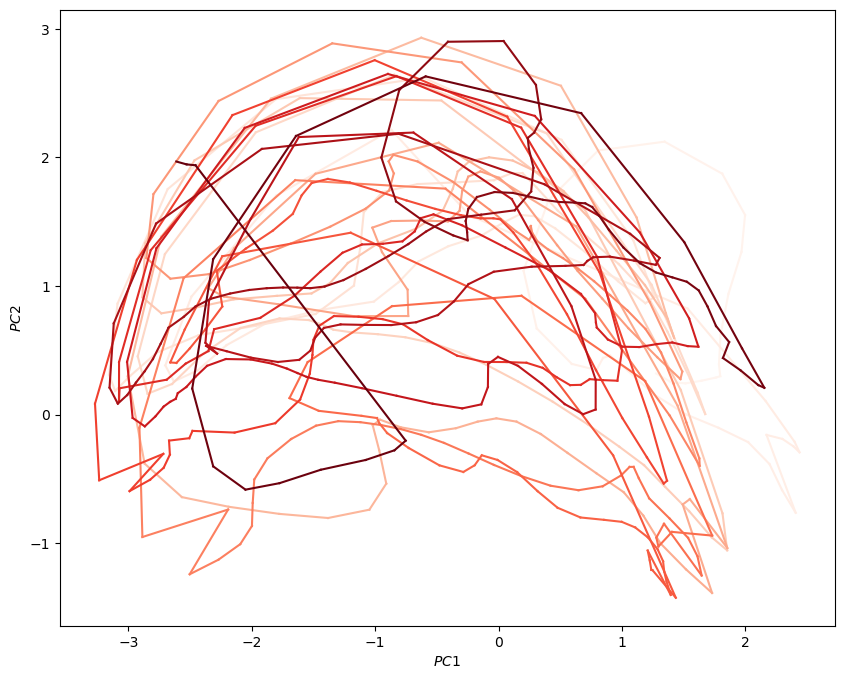

In [185]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot()

idx = 1
for p in  range(600*idx, 600*(idx+1)):
    i,j = [xf_transformed[0][p], xf_transformed[0][p+1]], [xf_transformed[1][p], xf_transformed[1][p+1]]
    ax.plot(i,j, color = plt.cm.Reds(norm(time)[p-(600*idx)]))


ax.set_xlabel('$PC1$', fontsize=10)
ax.set_ylabel('$PC2$', fontsize=10)

Text(0.5, 0, '$PC3$')

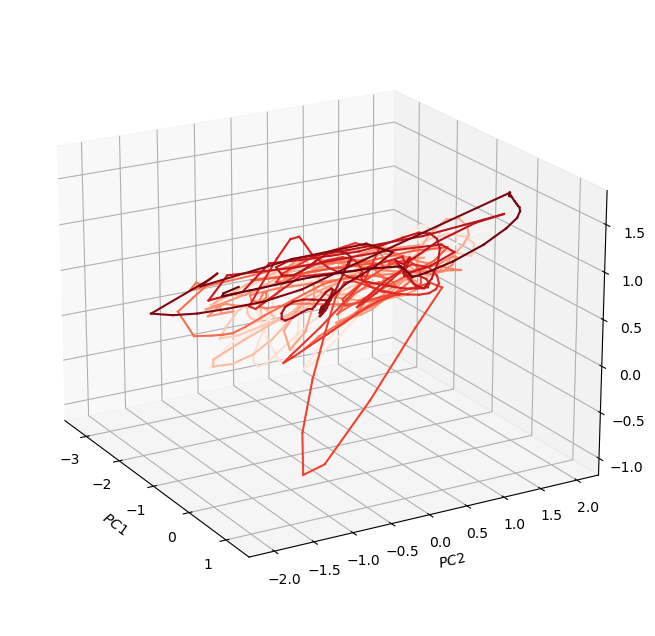

In [186]:
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(projection="3d")
ax.view_init(20, -30)
## Red == IN; Blue == OUT
idx = 25 ## trail number (of total) to plot
for p in  range(600*idx, 600*(idx+1)):
    i,j,k = [xf_transformed[0][p], xf_transformed[0][p+1]], [xf_transformed[1][p], xf_transformed[1][p+1]],[xf_transformed[2][p], xf_transformed[2][p+1]]
    ax.plot(i,j,k, color = plt.cm.Reds(norm(time)[p-(600*idx)]))


ax.set_xlabel('$PC1$', fontsize=10)
ax.set_ylabel('$PC2$', fontsize=10)
ax.set_zlabel('$PC3$', fontsize=10)